In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [12]:
df = pd.read_csv('raw.csv')

In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
df.shape

(1000, 8)

In [15]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [19]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [20]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [21]:
print("Categories in 'gender' Variable:  ",df['gender'].unique())

Categories in 'gender' Variable:   ['female' 'male']


In [22]:
print("Categories in 'race_ethnicity' Variable:  ",df['race_ethnicity'].unique())

Categories in 'race_ethnicity' Variable:   ['group B' 'group C' 'group A' 'group D' 'group E']


In [23]:
print("Categories in 'parental_level_of_education' Variable:  ",df['parental_level_of_education'].unique())

Categories in 'parental_level_of_education' Variable:   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [24]:
print("Categories in 'lunch' Variable:  ",df['lunch'].unique())

Categories in 'lunch' Variable:   ['standard' 'free/reduced']


In [25]:
print("Categorical in 'test_preparation_course' Variable: ",df['test_preparation_course'].unique())

Categorical in 'test_preparation_course' Variable:  ['none' 'completed']


In [26]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']

print('Numeric Features: {}'.format(len(numeric_features),numeric_features))
print('Categorical Features: {}'.format(len(categorical_features),categorical_features))

Numeric Features: 3
Categorical Features: 5


In [27]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [29]:
df['total score']= df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,229,76.333333


In [31]:
reading_full= df[df['reading_score'] == 100]['average'].count()
writing_full= df[df['writing_score'] ==100]['average'].count()
math_full= df[df['math_score'] ==100]['average'].count()

print("Number of students with full marks in Reading: ", reading_full)
print("Number of students with full marks in Writing: ", writing_full)
print("Number of students with full marks in Math: ", math_full)

Number of students with full marks in Reading:  17
Number of students with full marks in Writing:  14
Number of students with full marks in Math:  7


In [33]:
reading_less_20 = df[df['reading_score']<=20]['average'].count()
writing_less_20 = df[df['writing_score']<=20]['average'].count()
math_less_20 = df[df['math_score']<=20]['average'].count()

print("Number of students with less than 20 in Reading: ", reading_less_20)
print("Number of students with less than 20 in Writing: ", writing_less_20)
print("Number of students with less than 20 in Math: ", math_less_20)

Number of students with less than 20 in Reading:  1
Number of students with less than 20 in Writing:  3
Number of students with less than 20 in Math:  4


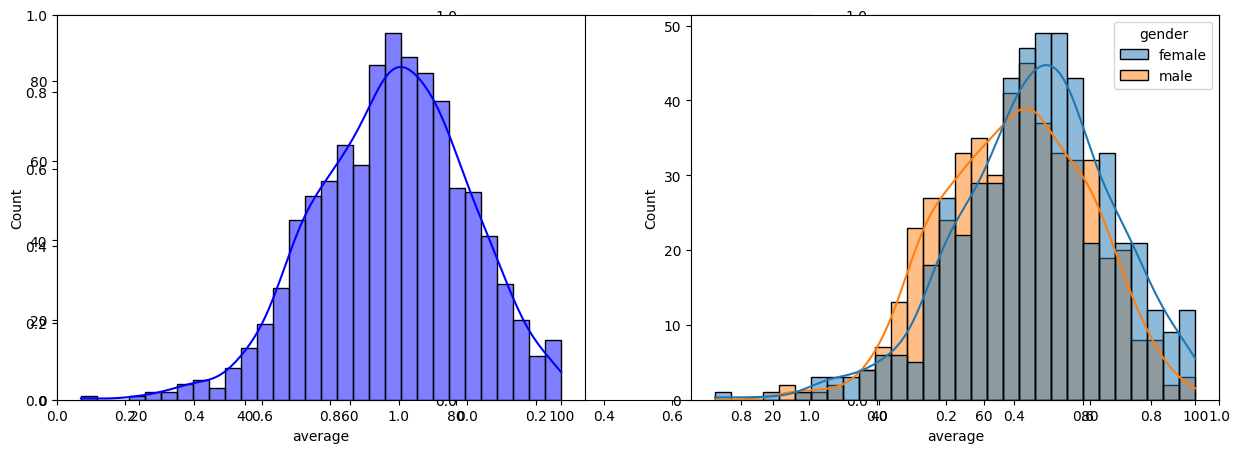

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt. subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='blue')
plt.subplot(122)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='gender')
plt.show()

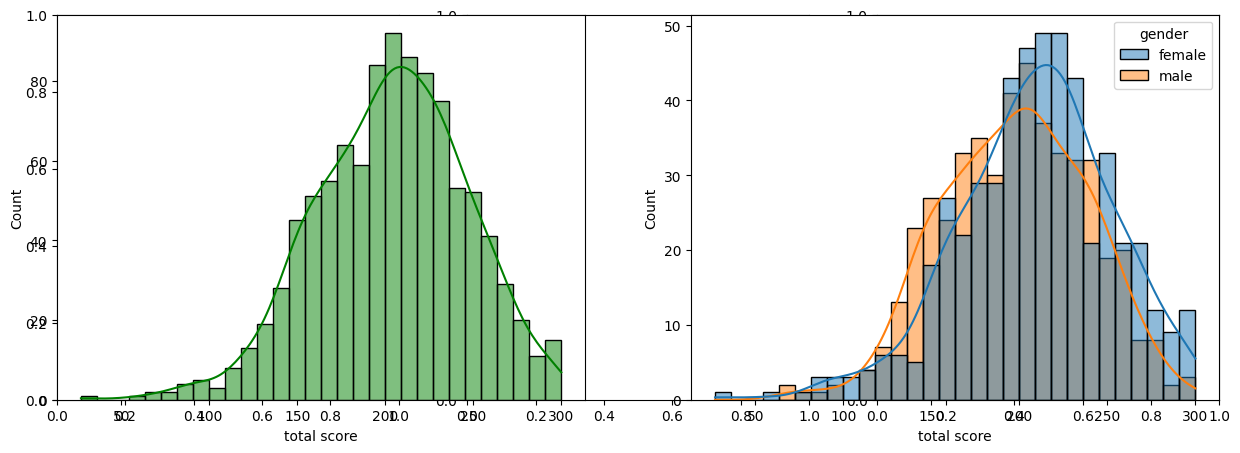

In [48]:
fig,axes= plt.subplots(1,3,figsize=(15,5))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30, kde=True,color= 'green')
plt.subplot(122)
sns.histplot(data=df,x='total score',bins=30, kde=True, hue='gender')
plt.show()

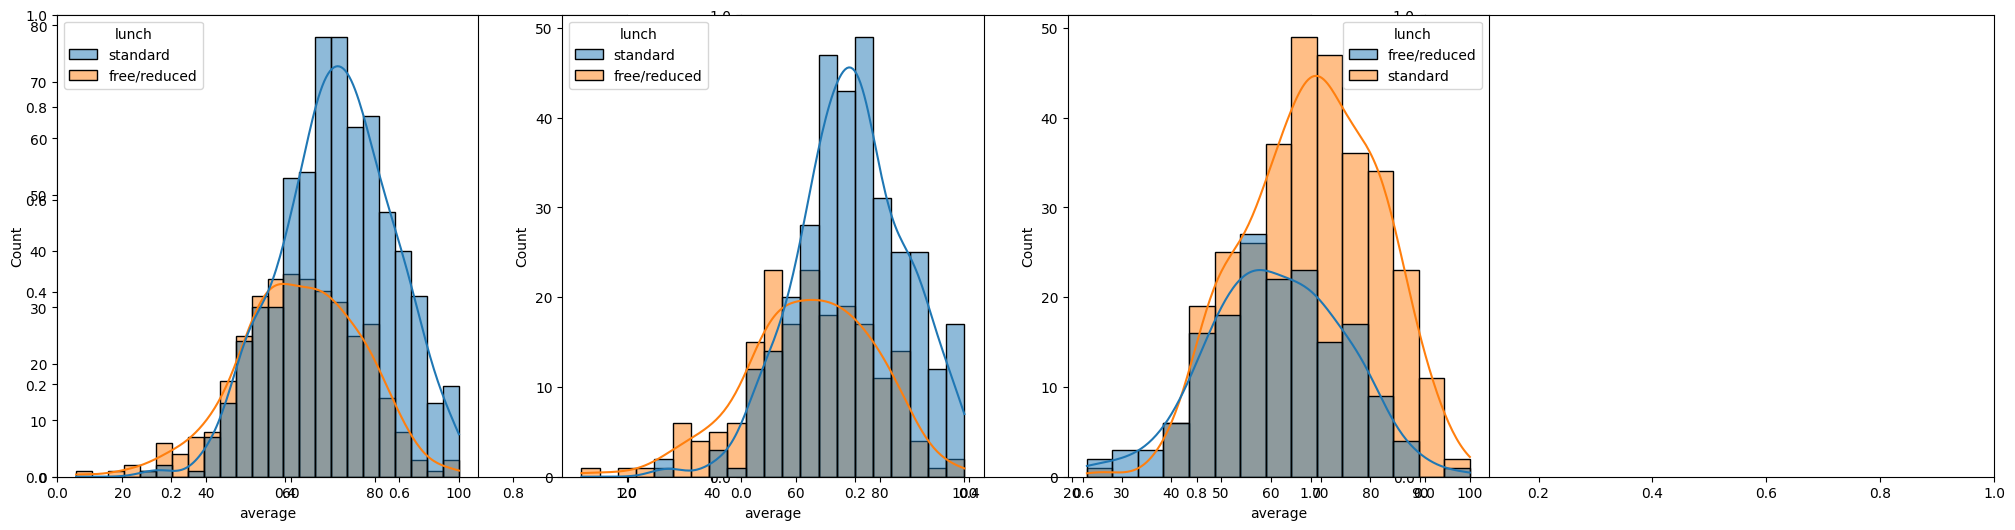

In [56]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data= df,x='average',kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data= df[df.gender=='female'],x='average',kde=True, hue='lunch',color='pink')
plt.subplot(143)
sns.histplot(data= df[df.gender=='male'],x='average',kde=True, hue='lunch',color='blue')
plt.show()

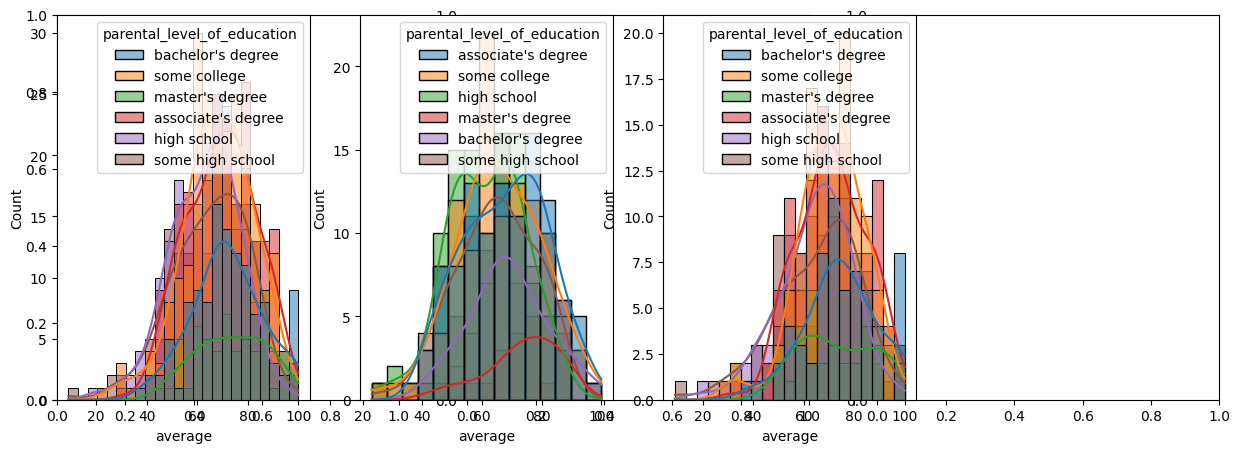

In [58]:
plt.subplots(1,3,figsize=(15,5))
plt.subplot(141)
sns.histplot(data= df,x='average',kde=True, hue='parental_level_of_education')
plt.subplot(142)
ax= sns.histplot(data= df[df.gender=='male'],x='average', kde=True, hue='parental_level_of_education',color='blue')
plt.subplot(143)
sns.histplot(data= df[df.gender=='female'],x='average', kde=True, hue='parental_level_of_education',color='pink')
plt.show()